# `mxalign`: Meteo-xAlign

**An xarray based package for alignment of meteorological data**

`mxalign` operates on `xr.Datasets` that conform to the contract defined in [`mlwp-data-specs`](https://github.com/mlwp-tools/mlwp-data-specs).

Different types of datasets can be loaded (and validated) with specific loaders from [`mlwp-data-loaders`](https://github.com/mlwp-tools/mlwp-data-specs)



Opening a dataset directly with `xarray` returns a an `xr.Dataset` exposing the internal structure of the data.

In [1]:
import xarray as xr
import numpy as np


ENDPOINT_URL = "https://object-store.os-api.cci2.ecmwf.int"
STORAGE_OPTS = {"endpoint_url": ENDPOINT_URL, "anon": True}

# netCDF file produced by anemoi-inference stored in an s3-bucket
DS_PATH = "s3://mlwp-sample-datasets/anemoi-inference/unknown-revision/anemoi-inference-lam_2020020100.nc"

# Using xarray to open the netCDF-file
ds_fcst1 = xr.open_dataset(
    DS_PATH,
    engine="h5netcdf",
    storage_options=STORAGE_OPTS,
    chunks="auto"
)
ds_fcst1

<xarray.Dataset> Size: 475MB
Dimensions:    (values: 1142761, time: 25)
Coordinates:
  * time       (time) datetime64[ns] 200B 2020-02-01 ... 2020-02-07
Dimensions without coordinates: values
Data variables:
    latitude   (values) float64 9MB dask.array<chunksize=(1142761,), meta=np.ndarray>
    longitude  (values) float64 9MB dask.array<chunksize=(1142761,), meta=np.ndarray>
    10u        (time, values) float64 229MB dask.array<chunksize=(13, 571381), meta=np.ndarray>
    2t         (time, values) float64 229MB dask.array<chunksize=(13, 571381), meta=np.ndarray>

As seen above, the returned dataset may need some additional processing before it can be used in a verification pipeline (e.g. the `latitude` and `longitude` are registed as data variables)

When loading a dataset with the `mlwp-data-loaders` package it returns an `xr.Dataset` and attaches Traits along 3 axes:

- **space**: _grid_, _point_
- **time**: _forecast_, _observation_, _climatology_
- **uncertainty**: _deterministic_, _ensemble_, _quantile_

Depending on the traits, pre-defined dimensions, coordinates and metadata are enforced.

In [2]:
# Using mxalign to open the netCDF-file
from mlwp_data_loaders import load_and_validate_dataset

LOADER = "mlwp_data_loaders.loaders.anemoi.anemoi_inference"

ds_fcst2, report = load_and_validate_dataset(
    DS_PATH, 
    loader=LOADER,
    storage_options=STORAGE_OPTS,
    return_validation_report=True
)
ds_fcst2

2026-06-23 12:20:18.922 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_dim_variants with {'axis': 'time', 'variants': [{'reference_time', 'lead_time'}]}
2026-06-23 12:20:18.923 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_required_coords with {'axis': 'time', 'required_coords': {'reference_time', 'lead_time'}}
2026-06-23 12:20:18.923 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_time_coordinate_metadata with {'trait': <Time.FORECAST: 'forecast'>}
2026-06-23 12:20:18.924 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_coordinate_attrs with {'section': 'Time Coordinate', 'requirement': "Metadata for coordinate 'reference_time'", 'coord': 'reference_time', 'required_attrs': {'standard_name': {'time', 'forecast_reference_time'}}}
2026-06-23 12:20:18.924 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_coordinate_attrs with {'section': 'Time Coordinate', 'require

<xarray.Dataset> Size: 475MB
Dimensions:         (grid_index: 1142761, reference_time: 1, lead_time: 25)
Coordinates:
    latitude        (grid_index) float64 9MB dask.array<chunksize=(1142761,), meta=np.ndarray>
    longitude       (grid_index) float64 9MB dask.array<chunksize=(1142761,), meta=np.ndarray>
  * reference_time  (reference_time) datetime64[ns] 8B 2020-02-01
  * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
Dimensions without coordinates: grid_index
Data variables:
    10u             (reference_time, lead_time, grid_index) float64 229MB dask.array<chunksize=(1, 13, 571381), meta=np.ndarray>
    2t              (reference_time, lead_time, grid_index) float64 229MB dask.array<chunksize=(1, 13, 571381), meta=np.ndarray>
Attributes:
    mlwp_time_trait:         forecast
    mlwp_space_trait:        grid
    mlwp_uncertainty_trait:  deterministic

`mlwp-data-loaders` can (`return_validation_report = True`) provide additional information in the form of a validation report

In [3]:
report.console_print()

                                                 Validation Report                                                 
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Section            ┃ Requirement               ┃ Status ┃ Detail                    ┃ Check Function            ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Time Coordinate    │ Allowed dimension         │   ✅   │ Dataset dims satisfy      │ traits._common.check_dim… │
│                    │ variants                  │        │ variant ['lead_time',     │                           │
│                    │                           │        │ 'reference_time']         │                           │
│ Time Coordinate    │ Required coordinates are  │   ✅   │ All required coordinates  │ traits._common.check_req… │
│                    │ present                   │        │ present: ['lead_time',    │                           │
│                    │                           │        │ 'reference_time']         │                           │
│ Time Coordinate    │ Metadata for coordinate   │   ✅   │ reference_time: metadata  │ metadata.coords.check_ti… │
│                    │ 'reference_time'          │        │ is compliant              │                           │
│ Time Coordinate    │ Metadata for coordinate   │   ✅   │ lead_time: metadata is    │ metadata.coords.check_ti… │
│                    │ 'lead_time'               │        │ compliant                 │                           │
│ Spatial Coordinate │ Allowed dimension         │   ✅   │ Dataset dims satisfy      │ traits._common.check_dim… │
│                    │ variants                  │        │ variant ['grid_index']    │                           │
│ Spatial Coordinate │ Required coordinates are  │   ✅   │ All required coordinates  │ traits._common.check_req… │
│                    │ present                   │        │ present: ['latitude',     │                           │
│                    │                           │        │ 'longitude']              │                           │
│ Spatial Coordinate │ Metadata for coordinate   │   ✅   │ longitude: metadata is    │ metadata.coords.check_sp… │
│                    │ 'longitude'               │        │ compliant                 │                           │
│ Spatial Coordinate │ Metadata for coordinate   │   ✅   │ latitude: metadata is     │ metadata.coords.check_sp… │
│                    │ 'latitude'                │        │ compliant                 │                           │
│ Uncertainty        │ Allowed dimension         │   ✅   │ No dimension restrictions │ traits._common.check_dim… │
│                    │ variants                  │        │                           │                           │
│ Uncertainty        │ Required coordinates are  │   ✅   │ No required coordinates   │ traits._common.check_req… │
│                    │ present                   │        │                           │                           │
│ Uncertainty        │ Deterministic mode        │   ✅   │ No uncertainty coordinate │ metadata.coords.check_un… │
│                    │ metadata                  │        │ required                  │                           │
└────────────────────┴───────────────────────────┴────────┴───────────────────────────┴───────────────────────────┘

Summary: 0 fail(s), 0 warning(s), 11 pass(es).

In [4]:
# The type of datasets is uniquely defined by its Traits (stored as attributes)
ds_fcst2.attrs

{'mlwp_time_trait': 'forecast',
 'mlwp_space_trait': 'grid',
 'mlwp_uncertainty_trait': 'deterministic'}

## Traits
Every trait comes with a _contract_: a required set of dimensions, dimension names and coordinates

### Space
**GRID**
- required dimensions: `(grid_index)` or `(lat, lon)` or `(yc, xc)`
- required coordinates: `(lat, lon)`

**OBSERVATION**
- required dimensions: `(point_index)`
- required dimensions: `(lat, lon)`

### Time
**FORECAST**
- required dimensions: `(reference_time, lead_time)`
- required coordinates: `(reference_time, lead_time)`

**OBSERVATION**
- required dimensions: `(valid_time)`
- required coordinates: `(valid_time)`

**CLIMATOLOGY**
TBD

### Uncertainty
**DETERMINISTIC**
- required dimensions: `null`
- required coordinates: `null`

**ENSEMBLE**
- required dimensions: `(member)`
- required coordinates: `(member)`

**QUANTILE**
- required dimensions: `(quantile)`
- required coordinates: `(quantile)`

When a dataset is loaded with `mxalign` the above specification get validated.

## Accessors
With datesets defined along the three Trait-axes, alignment methods can be inferred from the datasets themselves.

For this the `mxalign` package adds an `mx` accessor to `xr.Datasets`

In [5]:
import mxalign as mx
# anemoi-inference forecasts
DS_PATH = [
    "s3://mlwp-sample-datasets/anemoi-inference/unknown-revision/"
    "anemoi-inference-lam_2020020100.nc",
    "s3://mlwp-sample-datasets/anemoi-inference/unknown-revision/"
    "anemoi-inference-lam_2020020200.nc",
]

ds_fcst = load_and_validate_dataset(
    DS_PATH, 
    loader=LOADER,
    storage_options=STORAGE_OPTS
)

ds_fcst

2026-06-23 12:20:26.417 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_dim_variants with {'axis': 'time', 'variants': [{'reference_time', 'lead_time'}]}
2026-06-23 12:20:26.418 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_required_coords with {'axis': 'time', 'required_coords': {'reference_time', 'lead_time'}}
2026-06-23 12:20:26.418 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_time_coordinate_metadata with {'trait': <Time.FORECAST: 'forecast'>}
2026-06-23 12:20:26.419 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_coordinate_attrs with {'section': 'Time Coordinate', 'requirement': "Metadata for coordinate 'reference_time'", 'coord': 'reference_time', 'required_attrs': {'standard_name': {'time', 'forecast_reference_time'}}}
2026-06-23 12:20:26.419 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_coordinate_attrs with {'section': 'Time Coordinate', 'require

<xarray.Dataset> Size: 932MB
Dimensions:         (reference_time: 2, lead_time: 25, grid_index: 1142761)
Coordinates:
  * reference_time  (reference_time) datetime64[ns] 16B 2020-02-01 2020-02-02
  * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
    latitude        (grid_index) float64 9MB 20.29 20.31 20.32 ... 63.81 63.77
    longitude       (grid_index) float64 9MB -17.49 -17.44 -17.4 ... 74.04 74.11
Dimensions without coordinates: grid_index
Data variables:
    10u             (reference_time, lead_time, grid_index) float64 457MB dask.array<chunksize=(1, 13, 571381), meta=np.ndarray>
    2t              (reference_time, lead_time, grid_index) float64 457MB dask.array<chunksize=(1, 13, 571381), meta=np.ndarray>
Attributes:
    mlwp_time_trait:         forecast
    mlwp_space_trait:        grid
    mlwp_uncertainty_trait:  deterministic

**Temporal accessor functions**

In [6]:
# TIME 
if ds_fcst.mx.is_forecast():
    print("Dataset is a forecast")
if ds_fcst.mx.is_observation():
    print("Dataset is an observation")

# Add an auxiliary valid time coordinate
ds_fcst = ds_fcst.mx.add_valid_time()
ds_fcst

Dataset is a forecast


<xarray.Dataset> Size: 932MB
Dimensions:         (reference_time: 2, lead_time: 25, grid_index: 1142761)
Coordinates:
  * reference_time  (reference_time) datetime64[ns] 16B 2020-02-01 2020-02-02
  * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
    valid_time      (reference_time, lead_time) datetime64[ns] 400B 2020-02-0...
    latitude        (grid_index) float64 9MB 20.29 20.31 20.32 ... 63.81 63.77
    longitude       (grid_index) float64 9MB -17.49 -17.44 -17.4 ... 74.04 74.11
Dimensions without coordinates: grid_index
Data variables:
    10u             (reference_time, lead_time, grid_index) float64 457MB dask.array<chunksize=(1, 13, 571381), meta=np.ndarray>
    2t              (reference_time, lead_time, grid_index) float64 457MB dask.array<chunksize=(1, 13, 571381), meta=np.ndarray>
Attributes:
    mlwp_time_trait:         forecast
    mlwp_space_trait:        grid
    mlwp_uncertainty_trait:  deterministic

**Spatial accessor functions**

In [7]:
# SPACE accessor
import cartopy.crs as ccrs

# Define a Coordinate Reference System (CRS)
globe_cerra = ccrs.Globe(semimajor_axis=6371229.0, semiminor_axis=6371229.0)
crs_cerra = ccrs.LambertConformal(
    central_longitude=8.0,
    central_latitude=50.0,
    standard_parallels=[50.0, 50.0],
    globe=globe_cerra,
)

# Add it to the dataset (this will enable other functionality)
ds_fcst = ds_fcst.mx.add_crs(crs_cerra)
ds_fcst

<xarray.Dataset> Size: 932MB
Dimensions:         (reference_time: 2, lead_time: 25, grid_index: 1142761)
Coordinates:
  * reference_time  (reference_time) datetime64[ns] 16B 2020-02-01 2020-02-02
  * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
    valid_time      (reference_time, lead_time) datetime64[ns] 400B 2020-02-0...
    latitude        (grid_index) float64 9MB 20.29 20.31 20.32 ... 63.81 63.77
    longitude       (grid_index) float64 9MB -17.49 -17.44 -17.4 ... 74.04 74.11
Dimensions without coordinates: grid_index
Data variables:
    10u             (reference_time, lead_time, grid_index) float64 457MB dask.array<chunksize=(1, 13, 571381), meta=np.ndarray>
    2t              (reference_time, lead_time, grid_index) float64 457MB dask.array<chunksize=(1, 13, 571381), meta=np.ndarray>
Attributes:
    mlwp_time_trait:         forecast
    mlwp_space_trait:        grid
    mlwp_uncertainty_trait:  deterministic
    crs:                     +proj=lcc +ellps=WGS84 +a=6371229.0 +b=6371229.0...

In [8]:
# Add native x and y coordinates (in this case Lambert Conformal)
ds_fcst = ds_fcst.mx.add_xy()
ds_fcst

<xarray.Dataset> Size: 951MB
Dimensions:         (reference_time: 2, lead_time: 25, grid_index: 1142761)
Coordinates:
  * reference_time  (reference_time) datetime64[ns] 16B 2020-02-01 2020-02-02
  * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
    valid_time      (reference_time, lead_time) datetime64[ns] 400B 2020-02-0...
    latitude        (grid_index) float64 9MB 20.29 20.31 20.32 ... 63.81 63.77
    longitude       (grid_index) float64 9MB -17.49 -17.44 -17.4 ... 74.04 74.11
    xc              (grid_index) float64 9MB -2.938e+06 -2.931e+06 ... 2.937e+06
    yc              (grid_index) float64 9MB -2.937e+06 -2.937e+06 ... 2.937e+06
Dimensions without coordinates: grid_index
Data variables:
    10u             (reference_time, lead_time, grid_index) float64 457MB dask.array<chunksize=(1, 13, 571381), meta=np.ndarray>
    2t              (reference_time, lead_time, grid_index) float64 457MB dask.array<chunksize=(1, 13, 571381), meta=np.ndarray>
Attributes:
    mlwp_time_trait:         forecast
    mlwp_space_trait:        grid
    mlwp_uncertainty_trait:  deterministic
    crs:                     +proj=lcc +ellps=WGS84 +a=6371229.0 +b=6371229.0...

In [9]:
# Adding a grid-mapping will enable unstacking of the grid
# Note that the cerra grid is predifined in the mxalign package
ds_fcst = ds_fcst.mx.add_grid_mapping("cerra")
ds_fcst

<xarray.Dataset> Size: 951MB
Dimensions:         (reference_time: 2, lead_time: 25, grid_index: 1142761)
Coordinates:
  * reference_time  (reference_time) datetime64[ns] 16B 2020-02-01 2020-02-02
  * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
    valid_time      (reference_time, lead_time) datetime64[ns] 400B 2020-02-0...
    latitude        (grid_index) float64 9MB 20.29 20.31 20.32 ... 63.81 63.77
    longitude       (grid_index) float64 9MB -17.49 -17.44 -17.4 ... 74.04 74.11
    xc              (grid_index) float64 9MB -2.938e+06 -2.931e+06 ... 2.937e+06
    yc              (grid_index) float64 9MB -2.937e+06 -2.937e+06 ... 2.937e+06
Dimensions without coordinates: grid_index
Data variables:
    10u             (reference_time, lead_time, grid_index) float64 457MB dask.array<chunksize=(1, 13, 571381), meta=np.ndarray>
    2t              (reference_time, lead_time, grid_index) float64 457MB dask.array<chunksize=(1, 13, 571381), meta=np.ndarray>
Attributes:
    mlwp_time_trait:         forecast
    mlwp_space_trait:        grid
    mlwp_uncertainty_trait:  deterministic
    crs:                     +proj=lcc +ellps=WGS84 +a=6371229.0 +b=6371229.0...
    grid_mapping:            {'lon_ll': -17.4859, 'lat_ll': 20.2923, 'lon_ur'...

In [10]:
# Unstack
ds_fcst = ds_fcst.mx.unstack()
ds_fcst

<xarray.Dataset> Size: 933MB
Dimensions:         (yc: 1069, xc: 1069, reference_time: 2, lead_time: 25)
Coordinates:
  * yc              (yc) float64 9kB -2.937e+06 -2.931e+06 ... 2.937e+06
  * xc              (xc) float64 9kB -2.937e+06 -2.931e+06 ... 2.937e+06
    latitude        (yc, xc) float64 9MB 20.29 20.31 20.32 ... 63.84 63.81 63.77
    longitude       (yc, xc) float64 9MB -17.49 -17.44 -17.4 ... 74.04 74.11
  * reference_time  (reference_time) datetime64[ns] 16B 2020-02-01 2020-02-02
  * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
    valid_time      (reference_time, lead_time) datetime64[ns] 400B 2020-02-0...
Data variables:
    10u             (reference_time, lead_time, yc, xc) float64 457MB dask.array<chunksize=(1, 13, 534, 1069), meta=np.ndarray>
    2t              (reference_time, lead_time, yc, xc) float64 457MB dask.array<chunksize=(1, 13, 534, 1069), meta=np.ndarray>
Attributes:
    mlwp_time_trait:         forecast
    mlwp_space_trait:        grid
    mlwp_uncertainty_trait:  deterministic
    crs:                     +proj=lcc +ellps=WGS84 +a=6371229.0 +b=6371229.0...
    grid_mapping:            {'nx': 1069, 'ny': 1069, 'lon_ll': -17.4859, 'la...

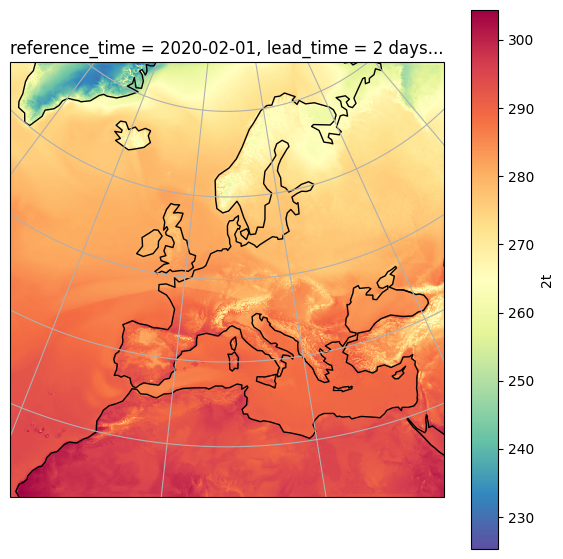

In [11]:
# Now we can plot the data on the native grid
import matplotlib.pyplot as plt

_ = (
    ds_fcst["2t"]
    .isel(reference_time=0, lead_time=10)
    .plot(
        x="xc",
        y="yc",
        figsize=(7, 7),
        subplot_kws={"projection": ds_fcst.attrs["crs"]},
        cmap="Spectral_r",
    )
)
_ = plt.gca().coastlines()
_ = plt.gca().gridlines()

## Loading
All loading of datasets is done through the central `load_and_validate_dataset` function

Often, you will need to load a specific dataset not conforming to the `mlwp-data-specs` contract.  
Since you know your dataset best, the `load_and_validate_dataset` function is compatible with your own loader.

You define your own loader by implementing the `load_dataset()` function

The final result of your loader should be an `xarray.Dataset` with a Trait on each of the 3 axes and the correct dimensions and coordinates.

For more information see [`mlwp-data-specs`](https://github.com/mlwp-tools/mlwp-data-specs)

You can use your own loader by pointing to the `.py` file 

In [12]:
DS_SYNOP = "s3://mxalign/mlwp-sample-datasets/custom/synop_20200201-20200207.nc"


In [13]:
ds_synop = xr.open_dataset(
    DS_SYNOP,
    engine="h5netcdf",
    storage_options={
        "endpoint_url": ENDPOINT_URL,
    }
)
ds_synop.load()

<xarray.Dataset> Size: 5MB
Dimensions:       (code: 1879, valid_time: 145)
Coordinates:
  * code          (code) int64 15kB 215734 215735 215736 ... 1020486 1595975
    wigos_id      (code) <U15 113kB '0-20000-0-13611' ... '0-20000-0-16204'
    wmo_code      (code) float64 15kB 1.361e+04 1.362e+04 ... 3.023e+03 1.62e+04
    station_name  (code) <U40 301kB 'DURRES' 'GJIROKASTRA' ... 'RADICOFANI'
    country_code  (code) <U2 15kB 'AL' 'AL' 'AL' 'AL' ... 'GB' 'GB' 'GB' 'IT'
    latitude      (code) float64 15kB 41.3 40.08 40.6 42.03 ... 57.12 57.33 42.9
    longitude     (code) float64 15kB 19.45 20.15 20.77 ... -3.633 -7.367 11.77
    altitude      (code) float64 15kB 15.0 193.0 889.0 ... 1.245e+03 10.0 816.0
    city_name     (code) <U40 301kB 'DURRES' 'GJIROKASTRA' ... 'RADICOFANI'
  * valid_time    (valid_time) datetime64[ns] 1kB 2020-02-01 ... 2020-02-07
Data variables:
    10si          (code, valid_time) float64 2MB 2.0 nan nan 2.0 ... nan nan nan
    2t            (code, valid_time) float64 2MB 10.0 nan nan ... nan nan nan

As you can see, the dataset almost conforms to the `mlwp-data-specs` contract. But we need to rename the `code` dimension to `point_index` and we need to provide the correct coordinate metadata.
Additionally we need to set the *traits* along the three axes.

We can do this by simply implementing the following function in the `myloader.py` file:
```python
def load_dataset(file):
    ds = xr.open_dataset(file, engine='h5netcdf')

    ds = ds.rename_dims(code="point_index")
    
    ds.attrs["mlwp_time_trait"] = "observation"
    ds.attrs["mlwp_space_trait"] = "point"
    ds.attrs["mlwp_uncertainty_trait"] = "deterministic"
    
    ds.coords["valid_time"].attrs["standard_name"] = "time"
    ds.coords["latitude"].attrs.update(
        {"standard_name": "latitude", "units": "degrees_north"}
    )
    ds.coords["longitude"].attrs.update(
        {"standard_name": "longitude", "units": "degrees_east"}
    )

    return ds
```

In [14]:
ds_synop = load_and_validate_dataset(
    DS_SYNOP,
    loader="myloader.py"
)
ds_synop

2026-06-23 12:20:37.647 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_dim_variants with {'axis': 'time', 'variants': [{'valid_time'}]}
2026-06-23 12:20:37.647 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_required_coords with {'axis': 'time', 'required_coords': {'valid_time'}}
2026-06-23 12:20:37.648 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_time_coordinate_metadata with {'trait': <Time.OBSERVATION: 'observation'>}
2026-06-23 12:20:37.648 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_coordinate_attrs with {'section': 'Time Coordinate', 'requirement': "Metadata for coordinate 'valid_time'", 'coord': 'valid_time', 'required_attrs': {'standard_name': {'time'}}}
2026-06-23 12:20:37.648 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_dim_variants with {'axis': 'space', 'variants': [{'point_index'}]}
2026-06-23 12:20:37.649 | INFO     | mlwp_data_specs.spec

<xarray.Dataset> Size: 5MB
Dimensions:       (point_index: 1879, valid_time: 145)
Coordinates:
  * code          (point_index) int64 15kB 215734 215735 ... 1020486 1595975
    wigos_id      (point_index) <U15 113kB dask.array<chunksize=(1879,), meta=np.ndarray>
    wmo_code      (point_index) float64 15kB dask.array<chunksize=(1879,), meta=np.ndarray>
    station_name  (point_index) <U40 301kB dask.array<chunksize=(1879,), meta=np.ndarray>
    country_code  (point_index) <U2 15kB dask.array<chunksize=(1879,), meta=np.ndarray>
    latitude      (point_index) float64 15kB dask.array<chunksize=(1879,), meta=np.ndarray>
    longitude     (point_index) float64 15kB dask.array<chunksize=(1879,), meta=np.ndarray>
    altitude      (point_index) float64 15kB dask.array<chunksize=(1879,), meta=np.ndarray>
    city_name     (point_index) <U40 301kB dask.array<chunksize=(1879,), meta=np.ndarray>
  * valid_time    (valid_time) datetime64[ns] 1kB 2020-02-01 ... 2020-02-07
Dimensions without coordinates: point_index
Data variables:
    10si          (point_index, valid_time) float64 2MB dask.array<chunksize=(1879, 145), meta=np.ndarray>
    2t            (point_index, valid_time) float64 2MB dask.array<chunksize=(1879, 145), meta=np.ndarray>
Attributes:
    mlwp_time_trait:         observation
    mlwp_space_trait:        point
    mlwp_uncertainty_trait:  deterministic

## Alignment
Alignment is space and time can now be automatically inferred from the dataset themselves

### Space

In [15]:
# Align a Grid with Point observations in space:
ds_fcst_aligned = ds_fcst.mx.align_space_with(ds_synop)
# This is quick because the interpolation itself is not yet executed, but rather lazely evaluated
ds_fcst_aligned

2026-06-23 12:20:39.235 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_dim_variants with {'axis': 'space', 'variants': [{'point_index'}]}
2026-06-23 12:20:39.236 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_required_coords with {'axis': 'space', 'required_coords': {'longitude', 'latitude'}}
2026-06-23 12:20:39.237 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_space_coordinate_metadata with {'trait': <Space.POINT: 'point'>}
2026-06-23 12:20:39.237 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_coordinate_attrs with {'section': 'Spatial Coordinate', 'requirement': "Metadata for coordinate 'longitude'", 'coord': 'longitude', 'required_attrs': {'standard_name': {'longitude'}, 'units': {'degrees_east'}}}
2026-06-23 12:20:39.238 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_coordinate_attrs with {'section': 'Spatial Coordinate', 'requirement': "Metadata for co

<xarray.Dataset> Size: 2MB
Dimensions:         (reference_time: 2, lead_time: 25, point_index: 1879)
Coordinates:
  * reference_time  (reference_time) datetime64[ns] 16B 2020-02-01 2020-02-02
  * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
    valid_time      (reference_time, lead_time) datetime64[ns] 400B 2020-02-0...
    latitude        (point_index) float64 15kB 41.3 40.08 40.6 ... 57.33 42.9
    longitude       (point_index) float64 15kB 19.45 20.15 ... -7.367 11.77
    xc              (point_index) float64 15kB 9.633e+05 1.044e+06 ... 3.091e+05
    yc              (point_index) float64 15kB -8.971e+05 ... -7.841e+05
Dimensions without coordinates: point_index
Data variables:
    10u             (reference_time, lead_time, point_index) float64 752kB dask.array<chunksize=(1, 5, 1879), meta=np.ndarray>
    2t              (reference_time, lead_time, point_index) float64 752kB dask.array<chunksize=(1, 5, 1879), meta=np.ndarray>
Attributes:
    mlwp_time_trait:         forecast
    mlwp_space_trait:        point
    mlwp_uncertainty_trait:  deterministic
    crs:                     +proj=lcc +ellps=WGS84 +a=6371229.0 +b=6371229.0...
    grid_mapping:            {'nx': 1069, 'ny': 1069, 'lon_ll': -17.4859, 'la...

As you can see, the `ds_fcst` dataset was transformed from `grid` to `point` along the *space_trait*. 

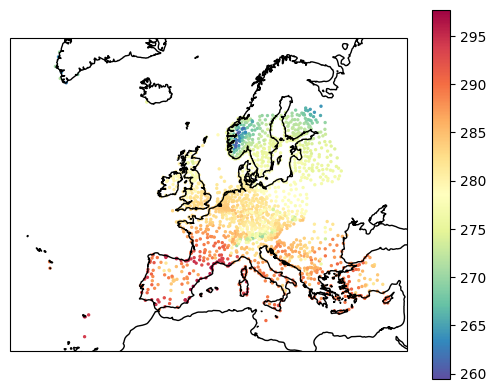

In [16]:
t2m_fcst = ds_fcst_aligned.isel(
    reference_time=0, 
    lead_time=10
)["2t"].compute()

ax = plt.subplot(1, 1, 1, projection=ds_fcst_aligned.attrs["crs"])
im = ax.scatter(
    x=t2m_fcst["xc"], y=t2m_fcst["yc"], c=t2m_fcst.values, cmap="Spectral_r", s=2
)
ax.coastlines()

plt.colorbar(im)

If you want to interpolate more than 1 dataset to a target dataset you can use the main `mxalign.interpolate` function. 

In [17]:
mx.available_interpolations()

['xarray', 'delaunay']

In [18]:
mx.interpolate(
    source_datasets=[ds_fcst, ],
    target_dataset=ds_synop,
    method="xarray"
)

2026-06-23 12:20:41.030 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_dim_variants with {'axis': 'space', 'variants': [{'point_index'}]}
2026-06-23 12:20:41.030 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_required_coords with {'axis': 'space', 'required_coords': {'longitude', 'latitude'}}
2026-06-23 12:20:41.031 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_space_coordinate_metadata with {'trait': <Space.POINT: 'point'>}
2026-06-23 12:20:41.031 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_coordinate_attrs with {'section': 'Spatial Coordinate', 'requirement': "Metadata for coordinate 'longitude'", 'coord': 'longitude', 'required_attrs': {'standard_name': {'longitude'}, 'units': {'degrees_east'}}}
2026-06-23 12:20:41.031 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_coordinate_attrs with {'section': 'Spatial Coordinate', 'requirement': "Metadata for co

<xarray.Dataset> Size: 2MB
Dimensions:         (reference_time: 2, lead_time: 25, point_index: 1879)
Coordinates:
  * reference_time  (reference_time) datetime64[ns] 16B 2020-02-01 2020-02-02
  * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
    valid_time      (reference_time, lead_time) datetime64[ns] 400B 2020-02-0...
    latitude        (point_index) float64 15kB 41.3 40.08 40.6 ... 57.33 42.9
    longitude       (point_index) float64 15kB 19.45 20.15 ... -7.367 11.77
    xc              (point_index) float64 15kB 9.633e+05 1.044e+06 ... 3.091e+05
    yc              (point_index) float64 15kB -8.971e+05 ... -7.841e+05
Dimensions without coordinates: point_index
Data variables:
    10u             (reference_time, lead_time, point_index) float64 752kB dask.array<chunksize=(1, 5, 1879), meta=np.ndarray>
    2t              (reference_time, lead_time, point_index) float64 752kB dask.array<chunksize=(1, 5, 1879), meta=np.ndarray>
Attributes:
    mlwp_time_trait:         forecast
    mlwp_space_trait:        point
    mlwp_uncertainty_trait:  deterministic
    crs:                     +proj=lcc +ellps=WGS84 +a=6371229.0 +b=6371229.0...
    grid_mapping:            {'nx': 1069, 'ny': 1069, 'lon_ll': -17.4859, 'la...

> Below code will fail on `NotImplementedError`, this is for illustration purposes

In [19]:
# The default interpolation is xarray-based, now lets try the Delaunay interpolation
ds_fcst_aligned2 = ds_fcst.mx.align_space_with(ds_synop, method="delaunay")

NotImplementedError: Delaunay interpolation currently only supports stacked grids

In [20]:
# Delaunay interpolation currently only works with stacked datasets.
ds_fcst = ds_fcst.mx.stack()
ds_fcst

<xarray.Dataset> Size: 951MB
Dimensions:         (reference_time: 2, lead_time: 25, grid_index: 1142761)
Coordinates:
  * reference_time  (reference_time) datetime64[ns] 16B 2020-02-01 2020-02-02
  * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
    valid_time      (reference_time, lead_time) datetime64[ns] 400B 2020-02-0...
    latitude        (grid_index) float64 9MB 20.29 20.31 20.32 ... 63.81 63.77
    longitude       (grid_index) float64 9MB -17.49 -17.44 -17.4 ... 74.04 74.11
    yc              (grid_index) float64 9MB -2.937e+06 -2.937e+06 ... 2.937e+06
    xc              (grid_index) float64 9MB -2.937e+06 -2.931e+06 ... 2.937e+06
Dimensions without coordinates: grid_index
Data variables:
    10u             (reference_time, lead_time, grid_index) float64 457MB dask.array<chunksize=(1, 13, 570846), meta=np.ndarray>
    2t              (reference_time, lead_time, grid_index) float64 457MB dask.array<chunksize=(1, 13, 570846), meta=np.ndarray>
Attributes:
    mlwp_time_trait:         forecast
    mlwp_space_trait:        grid
    mlwp_uncertainty_trait:  deterministic
    crs:                     +proj=lcc +ellps=WGS84 +a=6371229.0 +b=6371229.0...
    grid_mapping:            {'nx': 1069, 'ny': 1069, 'lon_ll': -17.4859, 'la...

In [21]:
# Now try the deleanay interpolation again
ds_fcst_aligned2 = ds_fcst.mx.align_space_with(ds_synop, method="delaunay")

Calculating interpolation-weight matrix


Delaunay interpolation: rechunking grid_index from 3 chunks to 1 (required for the sparse weight matmul).
Delaunay interpolation: rechunking grid_index from 3 chunks to 1 (required for the sparse weight matmul).
2026-06-23 12:21:02.234 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_dim_variants with {'axis': 'space', 'variants': [{'point_index'}]}
2026-06-23 12:21:02.235 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_required_coords with {'axis': 'space', 'required_coords': {'longitude', 'latitude'}}
2026-06-23 12:21:02.235 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_space_coordinate_metadata with {'trait': <Space.POINT: 'point'>}
2026-06-23 12:21:02.235 | INFO     | mlwp_data_specs.specs.reporting:wrapper:41 - Applying check_coordinate_attrs with {'section': 'Spatial Coordinate', 'requirement': "Metadata for coordinate 'longitude'", 'coord': 'longitude', 'required_attrs': {'standard_name': {'longitude'}, 

Done


In [22]:
result1 = ds_fcst_aligned.compute()
result2 = ds_fcst_aligned2.compute()

In [23]:
# Difference in interpolation methods
t2m_difference = (result2 - result1)["2t"]
np.abs(t2m_difference).mean()

<xarray.DataArray '2t' ()> Size: 8B
array(0.03928614)
Attributes:
    fill_value:  nan

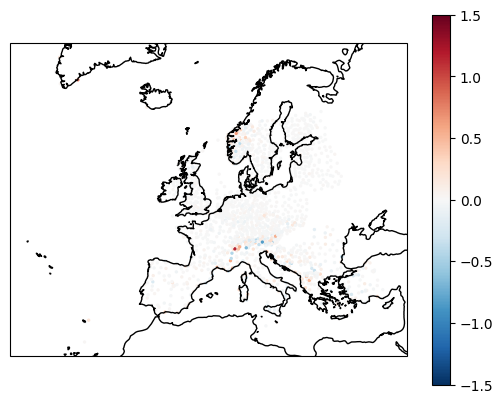

In [24]:
ax = plt.subplot(1, 1, 1, projection=ds_fcst_aligned.attrs["crs"])
im = ax.scatter(
    x=t2m_difference["xc"],
    y=t2m_difference["yc"],
    c=t2m_difference.isel(reference_time=0, lead_time=10).values,
    cmap="RdBu_r",
    s=2,
    vmax=1.5,
    vmin=-1.5
)
ax.coastlines()
plt.colorbar(im)

### Time

In [25]:
# Now align in time
# align the observations with the forecasts (so we can average over the lead times)
ds_obs_aligned = ds_synop.mx.align_time_with(ds_fcst_aligned)
ds_obs_aligned.load()

<xarray.Dataset> Size: 2MB
Dimensions:         (point_index: 1879, reference_time: 2, lead_time: 25)
Coordinates:
  * code            (point_index) int64 15kB 215734 215735 ... 1020486 1595975
    wigos_id        (point_index) <U15 113kB '0-20000-0-13611' ... '0-20000-0...
    wmo_code        (point_index) float64 15kB 1.361e+04 1.362e+04 ... 1.62e+04
    station_name    (point_index) <U40 301kB 'DURRES' ... 'RADICOFANI'
    country_code    (point_index) <U2 15kB 'AL' 'AL' 'AL' ... 'GB' 'GB' 'IT'
    latitude        (point_index) float64 15kB 41.3 40.08 40.6 ... 57.33 42.9
    longitude       (point_index) float64 15kB 19.45 20.15 ... -7.367 11.77
    altitude        (point_index) float64 15kB 15.0 193.0 889.0 ... 10.0 816.0
    city_name       (point_index) <U40 301kB 'DURRES' ... 'RADICOFANI'
  * reference_time  (reference_time) datetime64[ns] 16B 2020-02-01 2020-02-02
  * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
    valid_time      (reference_time, lead_time) datetime64[ns] 400B 2020-02-0...
Dimensions without coordinates: point_index
Data variables:
    10si            (point_index, reference_time, lead_time) float64 752kB 2....
    2t              (point_index, reference_time, lead_time) float64 752kB 10...
Attributes:
    mlwp_time_trait:         forecast
    mlwp_space_trait:        point
    mlwp_uncertainty_trait:  deterministic

## Transformations
Often, the variables themselves need some transformations before different datasets can be compared.  
When working interactively, this is easiest by interacting directly on the xr.Datasets.

But this can also be done using the `mxalign.transform` function.

In [26]:
mx.available_transformations()

['rename', 'kelvin_to_celcius', 'uv_to_speed', 'external']

In [27]:
ds_fcst_transformed = mx.transform(
    "kelvin_to_celcius", ds_fcst_aligned2, variables=["2t"]
)

# ds_fcst_transformed = mx.transform(
#     "external",
#     ds_fcst_transformed,
#     "earthkit.meteo.wind.speed",
#     inputs={"u": "10u", "v": "10v"},
#     output="10si",
# )

ds_fcst_transformed.compute()

<xarray.Dataset> Size: 2MB
Dimensions:         (reference_time: 2, lead_time: 25, point_index: 1879)
Coordinates:
  * reference_time  (reference_time) datetime64[ns] 16B 2020-02-01 2020-02-02
  * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
  * code            (point_index) int64 15kB 215734 215735 ... 1020486 1595975
    wigos_id        (point_index) <U15 113kB '0-20000-0-13611' ... '0-20000-0...
    wmo_code        (point_index) float64 15kB 1.361e+04 1.362e+04 ... 1.62e+04
    station_name    (point_index) <U40 301kB 'DURRES' ... 'RADICOFANI'
    country_code    (point_index) <U2 15kB 'AL' 'AL' 'AL' ... 'GB' 'GB' 'IT'
    latitude        (point_index) float64 15kB 41.3 40.08 40.6 ... 57.33 42.9
    longitude       (point_index) float64 15kB 19.45 20.15 ... -7.367 11.77
    altitude        (point_index) float64 15kB 15.0 193.0 889.0 ... 10.0 816.0
    city_name       (point_index) <U40 301kB 'DURRES' ... 'RADICOFANI'
Dimensions without coordinates: point_index
Data variables:
    10u             (reference_time, lead_time, point_index) float64 752kB -1...
    2t              (reference_time, lead_time, point_index) float64 752kB 11...
Attributes:
    mlwp_time_trait:         forecast
    mlwp_space_trait:        point
    mlwp_uncertainty_trait:  deterministic
    crs:                     +proj=lcc +ellps=WGS84 +a=6371229.0 +b=6371229.0...
    grid_mapping:            {'nx': 1069, 'ny': 1069, 'lon_ll': -17.4859, 'la...

With both observations and forecats completely aligned (space, time, and units). We can calculate some scores

In [28]:
# Calculate MSE by hand
mse = (ds_obs_aligned - ds_fcst_transformed) ** 2
mse.compute()

<xarray.Dataset> Size: 2MB
Dimensions:         (point_index: 1879, reference_time: 2, lead_time: 25)
Coordinates:
  * code            (point_index) int64 15kB 215734 215735 ... 1020486 1595975
    wigos_id        (point_index) <U15 113kB '0-20000-0-13611' ... '0-20000-0...
    wmo_code        (point_index) float64 15kB 1.361e+04 1.362e+04 ... 1.62e+04
    station_name    (point_index) <U40 301kB 'DURRES' ... 'RADICOFANI'
    country_code    (point_index) <U2 15kB 'AL' 'AL' 'AL' ... 'GB' 'GB' 'IT'
    latitude        (point_index) float64 15kB 41.3 40.08 40.6 ... 57.33 42.9
    longitude       (point_index) float64 15kB 19.45 20.15 ... -7.367 11.77
    altitude        (point_index) float64 15kB 15.0 193.0 889.0 ... 10.0 816.0
    city_name       (point_index) <U40 301kB 'DURRES' ... 'RADICOFANI'
  * reference_time  (reference_time) datetime64[ns] 16B 2020-02-01 2020-02-02
  * lead_time       (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 da...
    valid_time      (reference_time, lead_time) datetime64[ns] 400B 2020-02-0...
Dimensions without coordinates: point_index
Data variables:
    2t              (point_index, reference_time, lead_time) float64 752kB 1....
Attributes:
    mlwp_time_trait:         forecast
    mlwp_space_trait:        point
    mlwp_uncertainty_trait:  deterministic
    crs:                     +proj=lcc +ellps=WGS84 +a=6371229.0 +b=6371229.0...
    grid_mapping:            {'nx': 1069, 'ny': 1069, 'lon_ll': -17.4859, 'la...

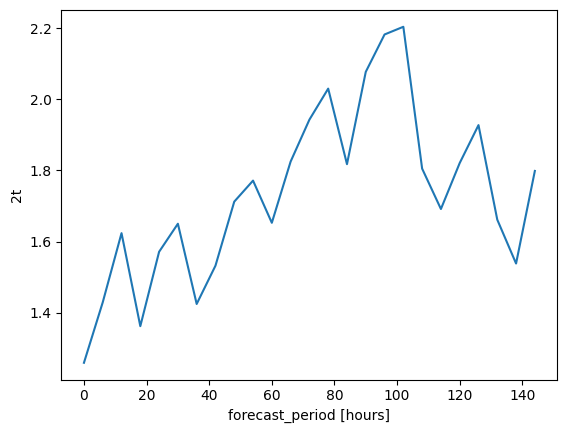

In [29]:
# Calculate RMSE by averaging over all dimension except lead time
rmse = np.sqrt(
    mse.mean(
        ["reference_time", "point_index"],
        skipna=True
    )
)

# Plot
rmse["2t"].assign_coords(
    lead_time_h=rmse.lead_time.astype("timedelta64[h]") / 3600
).plot(x="lead_time_h")

In [30]:
# Or use some specialized packages
import xskillscore as xs

vars = ["2t"] #, "10si", "msl", "2d"]
rmse_2 = xs.rmse(
    a=ds_fcst_transformed[vars].chunk({"reference_time":-1}),
    b=ds_obs_aligned[vars],
    dim=["reference_time", "point_index"],
    skipna=True
)
rmse_2.compute()

<xarray.Dataset> Size: 400B
Dimensions:    (lead_time: 25)
Coordinates:
  * lead_time  (lead_time) timedelta64[ns] 200B 0 days 00:00:00 ... 6 days 00...
Data variables:
    2t         (lead_time) float64 200B 1.259 1.429 1.624 ... 1.662 1.538 1.799

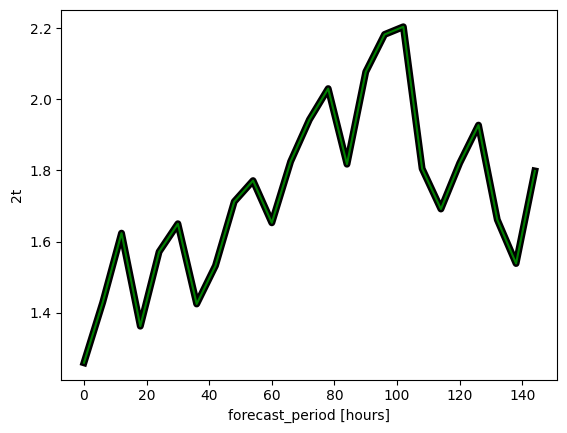

: 

In [ ]:
# Plot both scores
rmse["2t"].assign_coords(
    lead_time_h=rmse.lead_time.astype("timedelta64[h]") / 3600
).plot(
    x="lead_time_h", 
    c="black",
    lw=5
)

ax = plt.gca()
rmse_2["2t"].assign_coords(
    lead_time_h=rmse.lead_time.astype("timedelta64[h]") / 3600
).plot(
    x="lead_time_h",
    ax=ax,
    c="green"
)
